In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import holidays

In [72]:
df_fi = pd.read_parquet("dane/interim/fact_inka_records_2023_2026.parquet")

In [73]:


polish_map = str.maketrans({
    "ą": "a", "ć": "c", "ę": "e", "ł": "l",
    "ń": "n", "ó": "o", "ś": "s", "ź": "z", "ż": "z",
    "Ą": "A", "Ć": "C", "Ę": "E", "Ł": "L",
    "Ń": "N", "Ó": "O", "Ś": "S", "Ź": "Z", "Ż": "Z"
})

def CleanName(text: str):
    # if pd.isna(text):
    #     return ""
    text = str(text)
    text = text.translate(polish_map)         # zamiana PL → ASCII 1:1
    text = text.lower()
    text = re.sub(r"[^a-z0-9]+", " ", text)   # zamiana reszty na spację
    text = re.sub(r"\s+", " ", text).strip()  # redukcja wielokrotnych spacji
    return text

def process_df(df):
    df = df.copy()

    # dodanie kolumny NazwaTowCleanName
    df["NazwaTowCleanName"] = df["NazwaTow"].astype(str).apply(CleanName)

    return df

def process_df_asid(df):
    df = df.copy()

    # dodanie kolumny NazwaAsortCleanName
    df["NazwaAsortCleanName"] = df["NazwaAsort"].astype(str).apply(CleanName)

    return df

In [74]:
df_fi = process_df(df_fi.copy())

In [75]:
df_fi = process_df_asid(df_fi.copy())

In [76]:
# ============================================================
# HARD WYKLUCZENIA
# Kategorie które nie pochodzą z magazynu centralnego SPAR
# lub nie są towarami fizycznymi
# ============================================================

# Prasa i gazety (osobny system zamawiania - kolportaż)
asid_prasa = {132, 133, 273}

# Kiosk - bilety, zapalniczki, leki, baterie (nie z magazynu)
asid_kiosk = {245, 277, 278, 279, 283, 284, 285, 288, 290, 293, 275}

# Doładowania telefoniczne i startery (usługi, nie towary)
asid_doladowania = {47, 48, 255, 290, 330, 331, 332, 334, 335, 337, 338}

# Opakowania i techniczne (nie towary handlowe)
asid_techniczne = {
    256,  # OPAKOWANIA ZWROTNE
    352,  # reklamówki
    247,  # OPAKOWANIA /przemysłowe
    254,  # xx KOSZTY / RABATY
    244,  # Domyślny DO WERYFIKACJI
    354,  # xinne
}

# Łączna lista wykluczeń
lista_hard_wykluczen = (
    asid_prasa |
    asid_kiosk |
    asid_doladowania |
    asid_techniczne
)

print(f"Łącznie do twardego wykluczenia: {len(lista_hard_wykluczen)} AsId")

df_fi_hard = df_fi.copy()

# Filtrowanie AsId
df_fi_hard = df_fi_hard[~df_fi_hard['AsId'].isin(lista_hard_wykluczen)]

# Filtrowanie dokumentów bez NrDok
df_fi_hard = df_fi_hard[df_fi_hard['NrDok'].notna()]

print(f"Przed: {len(df_fi):,} rekordów")
print(f"Po:    {len(df_fi_hard):,} rekordów")
print(f"Usunięto: {len(df_fi) - len(df_fi_hard):,} rekordów")

Łącznie do twardego wykluczenia: 30 AsId
Przed: 4,260,543 rekordów
Po:    4,106,901 rekordów
Usunięto: 153,642 rekordów


## Jak wykluczyc produkty( TowId) które nie są sprzedawane od jakiegoś czasu

potrzeba policzyć datę ostatniej sprzedaży per TowId i porównać ją z datą odniesienia (koniec danych albo dzisiejsza data). Produkty, które "milczą" dłużej niż przyjęty próg  oznaczasz jako dead stock / do wykluczenia.


In [77]:
# ============================================================
# Ostatnia sprzedaż per TowId + wykluczenie "martwych" produktów
# ============================================================

# 1. Tylko rekordy sprzedaży
df_sprzedaz = df_fi_hard[df_fi_hard['TypRuchu'] == 'sprzedaz'].copy()

# 2. Data odniesienia — koniec zakresu danych (albo pd.Timestamp.now(), jeśli wolisz "dziś")
data_odniesienia = df_fi_hard['Data'].max()
print(f"Data odniesienia: {data_odniesienia}")

# 3. Ostatnia sprzedaż per TowId
ostatnia_sprzedaz = (
    df_sprzedaz
    .groupby('TowId')['Data']
    .max()
    .reset_index()
    .rename(columns={'Data': 'OstatniaSprzedaz'})
)

ostatnia_sprzedaz['DniOdOstatniejSprzedazy'] = (
    data_odniesienia - ostatnia_sprzedaz['OstatniaSprzedaz']
).dt.days


Data odniesienia: 2026-01-31 00:00:00


In [78]:
#  Progi rotacji wyliczone z percentyli rzeczywistego rozkładu

percentyle = ostatnia_sprzedaz['DniOdOstatniejSprzedazy'].quantile(
    [0.10, 0.25, 0.50, 0.75, 0.80, 0.90, 0.95, 0.99]
)
print(percentyle)

0       0
0       3
0     101
1     543
1     655
1     879
1   1,013
1   1,102
Name: DniOdOstatniejSprzedazy, dtype: float64


In [79]:
# 4. Próg "martwego" produktu obliczone poniżej
prog_dni = 550 # patrz komórka wyżej

towid_martwe = ostatnia_sprzedaz[
    ostatnia_sprzedaz['DniOdOstatniejSprzedazy'] > prog_dni
]['TowId']

print(f"TowId z ostatnią sprzedażą >{prog_dni} dni temu: {len(towid_martwe)} pozycji")

# 5. TowId, które W OGÓLE nie mają sprzedaży w danych (np. tylko przyjęcia, zwroty itp.)
wszystkie_towid = df_fi_hard['TowId'].unique()
towid_bez_sprzedazy = set(wszystkie_towid) - set(ostatnia_sprzedaz['TowId'])
print(f"TowId bez żadnej sprzedaży w okresie: {len(towid_bez_sprzedazy)} pozycji")

# 6. Finalna lista do wykluczenia
towid_do_wykluczenia = set(towid_martwe) | towid_bez_sprzedazy

df_fi_soft = df_fi_hard[~df_fi_hard['TowId'].isin(towid_do_wykluczenia)].copy()

print(f"Przed: {len(df_fi_hard):,} rekordów, {df_fi_hard['TowId'].nunique():,} TowId pozycji")
print(f"Po:    {len(df_fi_soft):,} rekordów, {df_fi_soft['TowId'].nunique():,} TowId pozycji")
print(f"Wykluczono: {len(towid_do_wykluczenia):,} TowId pozycji")

TowId z ostatnią sprzedażą >550 dni temu: 3097 pozycji
TowId bez żadnej sprzedaży w okresie: 7211 pozycji
Przed: 4,106,901 rekordów, 19,692 TowId pozycji
Po:    3,877,845 rekordów, 9,384 TowId pozycji
Wykluczono: 10,308 TowId pozycji


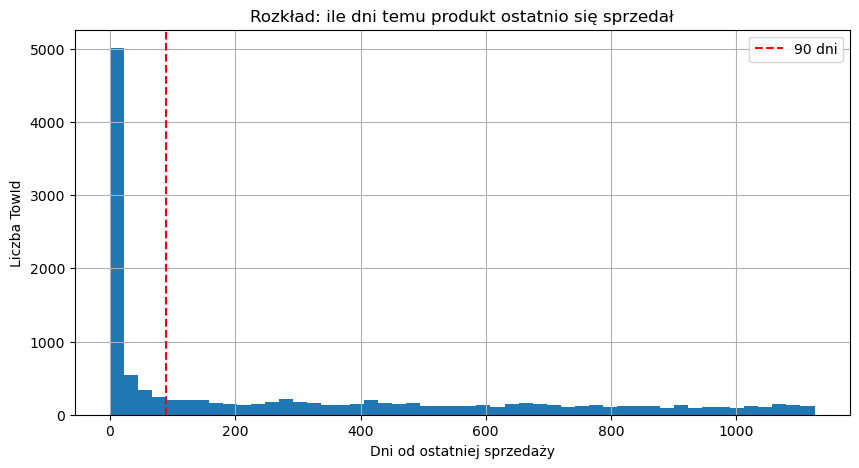

count   12,481
mean       292
std        350
min          0
25%          3
50%        101
75%        543
max      1,125
Name: DniOdOstatniejSprzedazy, dtype: float64

Percentyle:
0     101
1     543
1     879
1   1,013
1   1,102
Name: DniOdOstatniejSprzedazy, dtype: float64


In [80]:



plt.figure(figsize=(10, 5))
ostatnia_sprzedaz['DniOdOstatniejSprzedazy'].hist(bins=50)
plt.axvline(90, color='red', linestyle='--', label='90 dni')
plt.xlabel('Dni od ostatniej sprzedaży')
plt.ylabel('Liczba TowId')
plt.title('Rozkład: ile dni temu produkt ostatnio się sprzedał')
plt.legend()
plt.show()

print(ostatnia_sprzedaz['DniOdOstatniejSprzedazy'].describe())
print("\nPercentyle:")
print(ostatnia_sprzedaz['DniOdOstatniejSprzedazy'].quantile([0.5, 0.75, 0.9, 0.95, 0.99]))

In [81]:
# Progi oparte na rzeczywistym kształcie rozkładu (median vs. duży skok do 75 percentyla)
prog_aktywny = 100     # ~mediana, tu kończy się gęsty szczyt
prog_zagrozony = 550   # ~75 percentyl, tu zaczyna się długi "ogon"
# powyżej 550 dni = martwy

def kategoria_rotacji(dni):
    if dni <= prog_aktywny:
        return 'aktywny'
    elif dni <= prog_zagrozony:
        return 'zagrozony'
    else:
        return 'martwy'

ostatnia_sprzedaz['KategoriaRotacji'] = ostatnia_sprzedaz['DniOdOstatniejSprzedazy'].apply(kategoria_rotacji)
print(ostatnia_sprzedaz['KategoriaRotacji'].value_counts())

KategoriaRotacji
aktywny      6234
zagrozony    3150
martwy       3097
Name: count, dtype: int64


## Czy warto wykluczac martwe

In [82]:
# Ile TowId w każdej kategorii i jaki mają udział w wartości sprzedaży
towid_kategoria = ostatnia_sprzedaz[['TowId', 'KategoriaRotacji']]

df_z_kategoria = df_sprzedaz.merge(towid_kategoria, on='TowId', how='left')

podsumowanie = df_z_kategoria.groupby('KategoriaRotacji').agg(
    LiczbaTowId=('TowId', 'nunique'),
    WartoscSprzedazy=('Wartosc', 'sum'),
    LiczbaTransakcji=('TowId', 'count')
).reset_index()

podsumowanie['UdzialProcentowy'] = (
    podsumowanie['WartoscSprzedazy'] / podsumowanie['WartoscSprzedazy'].sum() * 100
).round(2)

print(podsumowanie)

  KategoriaRotacji  LiczbaTowId  WartoscSprzedazy  LiczbaTransakcji  UdzialProcentowy
0          aktywny         6234        15,687,898           2952692                87
1           martwy         3097           698,867            128113                 4
2        zagrozony         3150         1,706,317            293170                 9


### czy martwe produkty kiedys sie dobrze sprzedawały

In [83]:
# Ile ŚREDNIO transakcji/wartości miał pojedynczy "martwy" TowId?
martwe_stats = df_z_kategoria[df_z_kategoria['KategoriaRotacji'] == 'martwy'].groupby('TowId').agg(
    Wartosc=('Wartosc', 'sum'),
    Transakcje=('TowId', 'count')
).reset_index()

print(martwe_stats.describe())
print("\nTop 10 martwych wg wartości historycznej:")
print(martwe_stats.sort_values('Wartosc', ascending=False).head(10))

       TowId  Wartosc  Transakcje
count  3,097    3,097       3,097
mean  51,201      226          41
std   20,406      457          82
min       74        1           1
25%   50,081       27           4
50%   54,343       91          12
75%   66,260      242          42
max   78,789    8,529       1,016

Top 10 martwych wg wartości historycznej:
      TowId  Wartosc  Transakcje
831   50771    8,529         913
897   51267    7,046         525
1142  52563    6,838         401
1465  54095    5,084         716
636   38284    4,883         261
721   49431    4,261         341
763   49968    4,008          66
1228  53141    3,963         690
1517  54237    3,951         567
1328  53647    3,939        1016


## Trzeba sprawdzić czy martwe produkty zostały wycofane ze sprzedazy czy tez jest to problem sezonowości

In [84]:
top10_towid = martwe_stats.sort_values('Wartosc', ascending=False).head(10)['TowId']

wzorzec_top10 = df_sprzedaz[df_sprzedaz['TowId'].isin(top10_towid)].copy()
wzorzec_top10['RokMiesiac'] = wzorzec_top10['Data'].dt.to_period('M')

sprzedaz_w_czasie = wzorzec_top10.groupby(['TowId', 'RokMiesiac'])['Wartosc'].sum().unstack(fill_value=0)
print(sprzedaz_w_czasie)

# Dołączmy nazwy dla kontekstu
nazwy = df_fi_hard[['TowId', 'NazwaTow']].drop_duplicates()
print(nazwy[nazwy['TowId'].isin(top10_towid)])

RokMiesiac  2023-01  2023-02  2023-03  2023-04  2023-05  2023-06  2023-07  2023-08  2023-09  2023-10  2023-11  2023-12  2024-01  2024-02  2024-03  2024-04  2024-05  2024-06  2024-07
TowId                                                                                                                                                                                
38284           317      244      601      391      535      377      715      559      793      351        0        0        0        0        0        0        0        0        0
49431           212      189      533      548      548      646      707      268      146      195      268        0        0        0        0        0        0        0        0
49968            20      290      420      650      330       70       95      600      270      313      150      340       60      150        0      100        0      150        0
50771           672    1,047    1,302    1,795    1,180    1,581      953        0        

In [85]:
# Zamiast pivotu z obciętym wyświetlaniem, sprawdźmy wprost ostatnią sprzedaż per TowId
top10_towid = martwe_stats.sort_values('Wartosc', ascending=False).head(10)['TowId']

ostatnia_sprzedaz_top10 = df_sprzedaz[df_sprzedaz['TowId'].isin(top10_towid)].groupby('TowId').agg(
    PierwszaSprzedaz=('Data', 'min'),
    OstatniaSprzedaz=('Data', 'max'),
    LiczbaMiesiecyZeSprzedaza=('Data', lambda x: x.dt.to_period('M').nunique())
).reset_index()

print(ostatnia_sprzedaz_top10.sort_values('OstatniaSprzedaz'))

   TowId PierwszaSprzedaz OstatniaSprzedaz  LiczbaMiesiecyZeSprzedaza
3  50771       2023-01-02       2023-07-29                          7
4  51267       2023-01-02       2023-08-12                          8
0  38284       2023-01-07       2023-10-11                         10
1  49431       2023-01-03       2023-11-18                         11
7  53647       2023-03-21       2024-02-16                         12
5  52563       2023-01-04       2024-03-14                         15
8  54095       2023-01-02       2024-04-30                         16
9  54237       2023-01-02       2024-06-01                         18
2  49968       2023-01-13       2024-06-12                         16
6  53141       2023-01-04       2024-07-20                         19


In [86]:
# A teraz sprawdzam jak zachowują się wszystkie martwe 
# Dla WSZYSTKICH martwych TowId 
martwe_towid = ostatnia_sprzedaz[ostatnia_sprzedaz['KategoriaRotacji'] == 'martwy']['TowId']

df_sprzedaz_martwe = df_sprzedaz[df_sprzedaz['TowId'].isin(martwe_towid)]

profil_martwych = df_sprzedaz_martwe.groupby('TowId').agg(
    PierwszaSprzedaz=('Data', 'min'),
    OstatniaSprzedaz=('Data', 'max'),
    LiczbaMiesiecyZeSprzedaza=('Data', lambda x: x.dt.to_period('M').nunique()),
    LiczbaTransakcji=('Data', 'count'),
    Wartosc=('Wartosc', 'sum')
).reset_index()

# Długość "życia" produktu w dniach
profil_martwych['DlugoscZyciaDni'] = (
    profil_martwych['OstatniaSprzedaz'] - profil_martwych['PierwszaSprzedaz']
).dt.days

print(profil_martwych[['LiczbaMiesiecyZeSprzedaza', 'LiczbaTransakcji', 'DlugoscZyciaDni']].describe())

       LiczbaMiesiecyZeSprzedaza  LiczbaTransakcji  DlugoscZyciaDni
count                      3,097             3,097            3,097
mean                           5                41              153
std                            4                82              155
min                            1                 1                0
25%                            2                 4               18
50%                            3                12              100
75%                            7                42              256
max                           19             1,016              571


In [87]:
# Miesiące ostatniej sprzedaży martwych produktów
profil_martwych['Ilość'] = profil_martwych['OstatniaSprzedaz'].dt.to_period('M')
rozklad_konca = profil_martwych['Ilość'].value_counts().sort_index()
print(f'Miesiąc {rozklad_konca}')

Miesiąc Ilość
2023-01    159
2023-02    179
2023-03    157
2023-04    166
2023-05    131
2023-06    136
2023-07    148
2023-08    155
2023-09    151
2023-10    168
2023-11    134
2023-12    184
2024-01    159
2024-02    163
2024-03    210
2024-04    204
2024-05    167
2024-06    169
2024-07    157
Freq: M, Name: count, dtype: int64


# Sezonowość

In [88]:
# Wykrycie czy TwoId są sezonowe, czy też nie.
# Dodajemy miesiąc do rekordów sprzedaży
df_sprzedaz['Miesiac'] = df_sprzedaz['Data'].dt.month
df_sprzedaz['Rok'] = df_sprzedaz['Data'].dt.year

# Sprawdzamy w ilu różnych miesiącach i latach dany TowId się sprzedawał
sezonowosc = df_sprzedaz.groupby('TowId').agg(
    LiczbaAktywnychMiesiecy=('Miesiac', 'nunique'),   # ile z 12 miesięcy ma sprzedaż
    LiczbaAktywnychLat=('Rok', 'nunique'),
    PierwszaSprzedaz=('Data', 'min'),
    OstatniaSprzedaz=('Data', 'max')
).reset_index()

# Produkt "całoroczny" sprzedaje się w ~10-12 miesiącach
# Produkt sezonowy sprzedaje się tylko w 1-4 miesiącach, ale powtarzalnie w tych samych
print(sezonowosc['LiczbaAktywnychMiesiecy'].describe())

count   12,481
mean         8
std          4
min          1
25%          4
50%          9
75%         12
max         12
Name: LiczbaAktywnychMiesiecy, dtype: float64


In [89]:
#  koncentracji sprzedaży w top 3 miesiącach,
# Suma wartości sprzedaży per TowId per miesiąc (agregacja po wszystkich latach)
sprzedaz_per_miesiac = df_sprzedaz.groupby(['TowId', 'Miesiac'])['Wartosc'].sum().reset_index()

def koncentracja_top3(grupa):
    total = grupa['Wartosc'].sum()
    top3 = grupa.nlargest(3, 'Wartosc')['Wartosc'].sum()
    return top3 / total if total > 0 else 0

koncentracja = (
    sprzedaz_per_miesiac
    .groupby('TowId')
    .apply(koncentracja_top3, include_groups=False)
    .reset_index()
)
koncentracja.columns = ['TowId', 'KoncentracjaTop3Miesiace']

print(koncentracja['KoncentracjaTop3Miesiace'].describe())

count   12,481
mean         1
std          0
min          0
25%          0
50%          1
75%          1
max          1
Name: KoncentracjaTop3Miesiace, dtype: float64


### Wniosek : Interpretacja:

Teoretyczne minimum dla równomiernego rozkładu sprzedaży na 12 miesięcy to 3/12 = 0.25 (top 3 miesiące = 25% wartości, jeśli wszystkie miesiące są równe). Twój min = 0.2655 jest bardzo blisko tej wartości — czyli są produkty praktycznie idealnie równomierne.
Mediana = 0.553 — to znaczy, że typowy produkt ma aż 55% swojej rocznej wartości skoncentrowane w zaledwie 3 z 12 miesięcy. To znacznie więcej niż losowe 25%.
75 percentyl = 0.92 — czyli jedna czwarta wszystkich TowId ma 92%+ wartości w 3 miesiącach — to bardzo silna koncentracja, praktycznie sezonowość podręcznikowa.

Wniosek, który zmienia wcześniejszą interpretację: mimo że mediana "aktywnych miesięcy" wynosiła 9 (sugerując sprzedaż "cały rok"), okazuje się, że większość produktów ma wyraźne szczyty sezonowe, nawet jeśli formalnie sprzedają się przez większość roku. To ma sens biznesowo — sklep spożywczy/detaliczny naturalnie ma wzorce: więcej przed świętami, w wakacje, itd., nawet dla produktów "całorocznych".

To jest ważne, bo potwierdza zasadność Twojej wcześniejszej obawy o sezonowość — bez tego uwzględnienia, część "martwych" (ostatnia sprzedaż dawno temu) może być błędnie zakwalifikowana, jeśli akurat mijamy się z ich sezonem szczytowym.

In [90]:
sezonowosc_pelna = sezonowosc.merge(koncentracja, on='TowId', how='left')

# Kryterium: silna koncentracja (>70%) I potwierdzona przez min. 2 lata historii
sezonowosc_pelna['PrawdopodobnieSezonowy'] = (
    (sezonowosc_pelna['KoncentracjaTop3Miesiace'] > 0.70) &
    (sezonowosc_pelna['LiczbaAktywnychLat'] >= 2)
)

print(sezonowosc_pelna['PrawdopodobnieSezonowy'].value_counts())
print(f"\n% sezonowych: {sezonowosc_pelna['PrawdopodobnieSezonowy'].mean()*100:.1f}%")

# Ile z martwych TowId to potencjalnie sezonowe?
sezonowosc_pelna_martwe = sezonowosc_pelna[sezonowosc_pelna['TowId'].isin(martwe_towid)]
print(f"\nWśród martwych ({len(martwe_towid)}): {sezonowosc_pelna_martwe['PrawdopodobnieSezonowy'].sum()} to prawdopodobnie sezonowe")

PrawdopodobnieSezonowy
False    10807
True      1674
Name: count, dtype: int64

% sezonowych: 13.4%

Wśród martwych (3097): 326 to prawdopodobnie sezonowe


Podsumowanie:

Ogółem 13.4% całego katalogu (1674 z 12481 TowId) wykazuje wzorzec silnej sezonowości (>70% wartości w 3 miesiącach, potwierdzone przez ≥2 lata historii).
Wśród martwych: 326 z 3097 (czyli 10.5%) to prawdopodobnie produkty sezonowe, błędnie zakwalifikowane jako martwe — 

Co to znaczy praktycznie: Twoja intuicja z wcześniejszej rozmowy była słuszna — sezonowość rzeczywiście zniekształca kategorię martwy, ale w umiarkowanej skali (10.5% tej grupy, nie większość). Reszta — 2771 z 3097 (89.5%) — to nadal prawdopodobnie faktycznie martwe produkty (potwierdzone też wcześniej medianą: 3 miesiące aktywności, 12 transakcji, brak długiej historii — profil niepasujący do sezonowości).

In [91]:
# Finalna, poprawiona kategoryzacja — z uwzględnieniem sezonowości
rotacja_finalna = ostatnia_sprzedaz.merge(
    sezonowosc_pelna[['TowId', 'PrawdopodobnieSezonowy']], 
    on='TowId', how='left'
)

def kategoria_rotacji_finalna(row):
    dni = row['DniOdOstatniejSprzedazy']
    sezonowy = row['PrawdopodobnieSezonowy']
    
    if dni <= 100:
        return 'aktywny'
    if sezonowy:
        return 'sezonowy_poza_sezonem'
    if dni <= 550:
        return 'zagrozony'
    return 'martwy'

rotacja_finalna['KategoriaRotacji'] = rotacja_finalna.apply(kategoria_rotacji_finalna, axis=1)
print(rotacja_finalna['KategoriaRotacji'].value_counts())

KategoriaRotacji
aktywny                  6234
martwy                   2771
zagrozony                2475
sezonowy_poza_sezonem    1001
Name: count, dtype: int64


### Oflagowanie produktów r 'aktywny  'wolno_rotujacy' 'zagrozony' 'martwy'
# Po powyzszej analizie stosuje oflagowanie kazdego produktu 

In [92]:
# ============================================================
# SOFT FILTER — Kryterium 1: Rotacja / martwe produkty
# BEZ USUWANIA — tylko flagowanie, decyzja o filtrze przy analizie
# ============================================================

# 1. Rekordy sprzedaży z df_fi_hard
df_sprzedaz = df_fi_hard[df_fi_hard['TypRuchu'] == 'sprzedaz'].copy()

# 2. Data odniesienia
data_odniesienia = df_fi_hard['Data'].max()

# 3. Ostatnia sprzedaż per TowId
ostatnia_sprzedaz = (
    df_sprzedaz
    .groupby('TowId')['Data']
    .max()
    .reset_index()
    .rename(columns={'Data': 'OstatniaSprzedaz'})
)
ostatnia_sprzedaz['DniOdOstatniejSprzedazy'] = (
    data_odniesienia - ostatnia_sprzedaz['OstatniaSprzedaz']
).dt.days


ostatnia_sprzedaz['KategoriaRotacji'] = ostatnia_sprzedaz['DniOdOstatniejSprzedazy'].apply(kategoria_rotacji)

# 4. TowId bez żadnej sprzedaży w ogóle
wszystkie_towid = df_fi_hard['TowId'].unique()
towid_bez_sprzedazy = set(wszystkie_towid) - set(ostatnia_sprzedaz['TowId'])

brak_sprzedazy_df = pd.DataFrame({
    'TowId': list(towid_bez_sprzedazy),
    'OstatniaSprzedaz': pd.NaT,
    'DniOdOstatniejSprzedazy': np.nan,
    'KategoriaRotacji': 'martwy'
})

rotacja_towid = pd.concat([ostatnia_sprzedaz, brak_sprzedazy_df], ignore_index=True)

print("Rozkład kategorii rotacji:")
print(rotacja_towid['KategoriaRotacji'].value_counts())

# 6. Dołączenie flag do CAŁEGO zbioru — bez usuwania żadnego rekordu
df_fi_soft = df_fi_hard.merge(
    rotacja_towid[['TowId', 'OstatniaSprzedaz', 'DniOdOstatniejSprzedazy', 'KategoriaRotacji']],
    on='TowId',
    how='left'
)

# 7. Dodatkowe, gotowe flagi boolowskie — do szybkiego filtrowania w analizach
df_fi_soft['JestMartwy'] = df_fi_soft['KategoriaRotacji'] == 'martwy'
df_fi_soft['JestAktywny'] = df_fi_soft['KategoriaRotacji'] == 'aktywny'
df_fi_soft['WymagaUwagi'] = df_fi_soft['KategoriaRotacji'].isin(['zagrozony', 'wolno_rotujacy'])

print(f"\nRekordów łącznie: {len(df_fi_soft):,} (bez zmian względem df_fi_hard: {len(df_fi_hard):,})")
print(f"TowId łącznie: {df_fi_soft['TowId'].nunique():,}")
# Zapis oflagowanych produktów do pliku Parquet z kompresją Zstandard (zstd)
df_fi_soft.to_parquet(
    "dane/interim/fact_inka_soft_flagged_rotacja.parquet",
    compression='zstd',
    index=False
)
print(f"Zapisano: {df_fi_soft.shape}")

Rozkład kategorii rotacji:
KategoriaRotacji
martwy       10308
aktywny       6234
zagrozony     3150
Name: count, dtype: int64

Rekordów łącznie: 4,106,901 (bez zmian względem df_fi_hard: 4,106,901)
TowId łącznie: 19,692
Zapisano: (4106901, 38)


### Uwaga tu dostalismy 10308 martwych a wczesniej było 3097 . Skąd ta rozbieność
 Co to za produkty - jakie mają dokumenty, jeśli nie sprzedaż?


In [93]:
# Co to za produkty - jakie mają dokumenty, jeśli nie sprzedaż?
sprawdz = df_fi_hard[df_fi_hard['TowId'].isin(towid_bez_sprzedazy)]
print(sprawdz['TypRuchu'].value_counts())
print(sprawdz['Dokument'].value_counts())

# Przykładowe nazwy
print(sprawdz[['TowId', 'NazwaTow', 'Dokument']].drop_duplicates().head(20))

TypRuchu
remanent        20708
bo              13765
neutralny       10265
przecena         4326
przesuniecie      156
przyjecie         153
strata            127
rozchod            41
rozbieznosc        28
Name: count, dtype: int64
Dokument
REM               20708
BO                13765
ZM_ST_VAT          8120
PRZEC              4314
PLAN_ZM_ST_VAT     2030
PZ                  153
ST                  127
PRZES               120
ZAM                 110
RW                   41
PRZES_GR             36
ROZB                 28
ZAMR_PRZEC           12
DF                    5
Name: count, dtype: int64
      TowId                                                     NazwaTow Dokument
201   52016                            PRZEC SAŁATKA JARZYNOWA 200G SPAR       ST
205   55315                   PRZEC ŚLEDŹ KOLOROWY PIEPRZ 900G SUPERFISH       ST
214   51435                            GALARETKA LEMONIADA ANANAS WINIAR       ST
215   51436                           GALARETKA WODA KOKOSOWA 40G WI

Wniosek: to nie są "martwe produkty" w sensie biznesowym, tylko produkty, których jedyny ślad w danych to operacje magazynowo-księgowe. Przykłady z tabeli (MASA KRÓWKOWA...ZAM, PAPIEROSY WINSTON...ZAM, KROPLE MENTHOL...ZAM) to zwykłe nazwy towarów — więc to nie jest kwestia "dziwnych" pozycji technicznych (te już wyleciały w hard-wykluczeniach), tylko normalnych produktów, które akurat w Twoim oknie danych 2023-2026 nigdy nie miały zarejestrowanej transakcji sprzedaży TypRuchu == 'sprzedaz', mimo że są np. na stanie (remanent, BO) albo były przecenione.

In [94]:
def kategoria_rotacji_v3(dni):
    if pd.isna(dni['DniOdOstatniejSprzedazy']):
        return 'nigdy_nie_sprzedany'   # osobna etykieta, nie "martwy"
    dni = dni['DniOdOstatniejSprzedazy']
    if dni <= 100:
        return 'aktywny'
    elif dni <= 550:
        return 'zagrozony'
    else:
        return 'martwy'

In [95]:
# ============================================================
# SOFT FILTER — Kryterium 1: Rotacja / martwe produkty
# BEZ USUWANIA — tylko flagowanie, decyzja o filtrze przy analizie
# Wersja finalna: z rozróżnieniem "martwy" vs "nigdy_nie_sprzedany" + sezonowość
# ============================================================

# 1. Rekordy sprzedaży z df_fi_hard
df_sprzedaz = df_fi_hard[df_fi_hard['TypRuchu'] == 'sprzedaz'].copy()

# 2. Data odniesienia
data_odniesienia = df_fi_hard['Data'].max()

# 3. Ostatnia sprzedaż per TowId (tylko dla TowId z choć jedną sprzedażą)
ostatnia_sprzedaz = (
    df_sprzedaz
    .groupby('TowId')['Data']
    .max()
    .reset_index()
    .rename(columns={'Data': 'OstatniaSprzedaz'})
)
ostatnia_sprzedaz['DniOdOstatniejSprzedazy'] = (
    data_odniesienia - ostatnia_sprzedaz['OstatniaSprzedaz']
).dt.days

# 4. Sezonowość — do odróżnienia "martwy" od "sezonowy poza sezonem"
df_sprzedaz['Miesiac'] = df_sprzedaz['Data'].dt.month
df_sprzedaz['Rok'] = df_sprzedaz['Data'].dt.year

sezonowosc = df_sprzedaz.groupby('TowId').agg(
    LiczbaAktywnychLat=('Rok', 'nunique'),
).reset_index()

sprzedaz_per_miesiac = df_sprzedaz.groupby(['TowId', 'Miesiac'])['Wartosc'].sum().reset_index()

def koncentracja_top2(grupa):
    total = grupa['Wartosc'].sum()
    top2 = grupa.nlargest(2, 'Wartosc')['Wartosc'].sum()
    return top2 / total if total > 0 else 0

'''liczy ona, jaki procent całkowitej wartości sprzedaży danego TowId przypada na 2 najlepsze miesiące
 (w skali roku, zsumowane po wszystkich latach).'''

koncentracja = (
    sprzedaz_per_miesiac
    .groupby('TowId')
    .apply(koncentracja_top2, include_groups=False)
    .reset_index()
)
koncentracja.columns = ['TowId', 'KoncentracjaTop2Miesiace']

sezonowosc = sezonowosc.merge(koncentracja, on='TowId', how='left')
sezonowosc['PrawdopodobnieSezonowy'] = (
    (sezonowosc['KoncentracjaTop2Miesiace'] > 0.70) &
    (sezonowosc['LiczbaAktywnychLat'] >= 2)
)

ostatnia_sprzedaz = ostatnia_sprzedaz.merge(
    sezonowosc[['TowId', 'PrawdopodobnieSezonowy']], on='TowId', how='left'
)

# 5. Kategoryzacja — TYLKO dla TowId z historią sprzedaży
def kategoria_rotacji(row):
    dni = row['DniOdOstatniejSprzedazy']
    sezonowy = row['PrawdopodobnieSezonowy']
    if dni <= 100:
        return 'aktywny'
    if sezonowy:
        return 'sezonowy_poza_sezonem'
    if dni <= 550:
        return 'zagrozony'
    return 'martwy'

ostatnia_sprzedaz['KategoriaRotacji'] = ostatnia_sprzedaz.apply(kategoria_rotacji, axis=1)

# 6. TowId BEZ żadnej sprzedaży w ogóle — osobna kategoria, NIE "martwy"
wszystkie_towid = df_fi_hard['TowId'].unique()
towid_bez_sprzedazy = set(wszystkie_towid) - set(ostatnia_sprzedaz['TowId'])

brak_sprzedazy_df = pd.DataFrame({
    'TowId': list(towid_bez_sprzedazy),
    'OstatniaSprzedaz': pd.NaT,
    'DniOdOstatniejSprzedazy': np.nan,
    'PrawdopodobnieSezonowy': False,
    'KategoriaRotacji': 'nigdy_nie_sprzedany'   # ← osobna etykieta
})

rotacja_towid = pd.concat([ostatnia_sprzedaz, brak_sprzedazy_df], ignore_index=True)

print("Rozkład kategorii rotacji:")
print(rotacja_towid['KategoriaRotacji'].value_counts())

# 7. Dołączenie flag do CAŁEGO zbioru — bez usuwania żadnego rekordu
df_fi_soft = df_fi_hard.merge(
    rotacja_towid[['TowId', 'OstatniaSprzedaz', 'DniOdOstatniejSprzedazy',
                    'PrawdopodobnieSezonowy', 'KategoriaRotacji']],
    on='TowId',
    how='left'
)

# 8. Gotowe flagi boolowskie — do szybkiego filtrowania w analizach
df_fi_soft['JestAktywny'] = df_fi_soft['KategoriaRotacji'] == 'aktywny'
df_fi_soft['JestSezonowyPozaSezonem'] = df_fi_soft['KategoriaRotacji'] == 'sezonowy_poza_sezonem'
df_fi_soft['WymagaUwagi'] = df_fi_soft['KategoriaRotacji'] == 'zagrozony'
df_fi_soft['JestMartwy'] = df_fi_soft['KategoriaRotacji'] == 'martwy'
df_fi_soft['NigdyNieSprzedany'] = df_fi_soft['KategoriaRotacji'] == 'nigdy_nie_sprzedany'

# Zbiorcza flaga — do prognozy sprzedaży (wyklucza obie "martwe" grupy, zostawia sezonowe)
df_fi_soft['WykluczZPrognozy'] = df_fi_soft['KategoriaRotacji'].isin(
    ['martwy', 'nigdy_nie_sprzedany']
)

print(f"\nRekordów łącznie: {len(df_fi_soft):,} (bez zmian względem df_fi_hard: {len(df_fi_hard):,})")
print(f"TowId łącznie: {df_fi_soft['TowId'].nunique():,}")

Rozkład kategorii rotacji:
KategoriaRotacji
nigdy_nie_sprzedany      7211
aktywny                  6234
martwy                   2904
zagrozony                2803
sezonowy_poza_sezonem     540
Name: count, dtype: int64

Rekordów łącznie: 4,106,901 (bez zmian względem df_fi_hard: 4,106,901)
TowId łącznie: 19,692


In [96]:
# Porównanie koncentracji przy różnej liczbie "top miesięcy"
def koncentracja_topN(grupa, n):
    total = grupa['Wartosc'].sum()
    topN = grupa.nlargest(n, 'Wartosc')['Wartosc'].sum()
    return topN / total if total > 0 else 0

for n in [2, 3, 4, 6]:
    konc = (
        sprzedaz_per_miesiac
        .groupby('TowId')
        .apply(lambda g: koncentracja_topN(g, n), include_groups=False)
    )
    print(f"Top {n} miesięcy — mediana koncentracji: {konc.median():.3f}, teoretyczne minimum: {n/12:.3f}")

Top 2 miesięcy — mediana koncentracji: 0.407, teoretyczne minimum: 0.167
Top 3 miesięcy — mediana koncentracji: 0.553, teoretyczne minimum: 0.250
Top 4 miesięcy — mediana koncentracji: 0.670, teoretyczne minimum: 0.333
Top 6 miesięcy — mediana koncentracji: 0.852, teoretyczne minimum: 0.500


In [97]:
# Czy jakikolwiek TowId ma więcej niż jedną kategorię rotacji?
sprawdzenie = df_fi_soft.groupby('TowId')['KategoriaRotacji'].nunique()
liczba_niespojnych = (sprawdzenie > 1).sum()

print(f"TowId z więcej niż 1 kategorią (powinno być 0): {liczba_niespojnych}")

if liczba_niespojnych == 0:
    print("✓ Wszystko spójne — merge zadziałał poprawnie.")
else:
    # jeśli jednak >0, pokaż przykłady do diagnozy
    problematyczne = sprawdzenie[sprawdzenie > 1].index
    print(df_fi_soft[df_fi_soft['TowId'].isin(problematyczne)][['TowId', 'KategoriaRotacji']].drop_duplicates())

TowId z więcej niż 1 kategorią (powinno być 0): 0
✓ Wszystko spójne — merge zadziałał poprawnie.


In [98]:
# Lista unikalnych martwych towarów
martwe_towary = (
    df_fi_soft[df_fi_soft['JestMartwy'] == True]
    [['TowId', 'NazwaTow', 'EAN', 'NazwaAsort', 'OstatniaSprzedaz', 'DniOdOstatniejSprzedazy']]
    .drop_duplicates(subset='TowId')
    .sort_values('DniOdOstatniejSprzedazy', ascending=False)
)

print(f"Liczba martwych towarów: {len(martwe_towary)}")
print(martwe_towary)
martwe_towary.to_parquet("dane/interim/martwe_towary.parquet", index=False, compression='zstd')

Liczba martwych towarów: 2904
         TowId                                          NazwaTow               EAN                         NazwaAsort OstatniaSprzedaz  DniOdOstatniejSprzedazy
9        37370                NAPÓJ GAZ BUT SCHWEPPES 0,9L TONIC 5,902,860,410,744                    NAPOJE GAZOWANE       2023-01-02                    1,125
150      54014                 KUBUŚ WATERRR KAKTUS 0,25L MASPEX 5,901,067,408,905                 NAPOJE NIEGAZOWANE       2023-01-02                    1,125
15       55178             PASTELLA ŚLIWKA Z BOCZKIEM 80G LISNER 5,900,344,026,931      JAJA I PASTY JAJECZNE /nabiał       2023-01-02                    1,125
234      55362    PRZEC KAWA MIEL STARBUCKS ESPRESSO 200G NESTLE           204,438                        ***PRZECENY       2023-01-02                    1,125
29       55334                           MARG FLORA 225G UPFIELD 8,719,200,236,769  MARGARYNY DO SMAROWANIA /tłuszcze       2023-01-02                    1,125
...       

In [99]:
# ============================================================
# Produkty sezonowe z wyraźnym szczytem w GRUDNIU
# ============================================================

# Wykorzystujemy już policzone sprzedaz_per_miesiac (suma Wartosc per TowId per Miesiac)
grudniowe = sprzedaz_per_miesiac[sprzedaz_per_miesiac['Miesiac'] == 12].copy()

# Łączna wartość sprzedaży całego roku per TowId (suma wszystkich miesięcy)
suma_roczna = sprzedaz_per_miesiac.groupby('TowId')['Wartosc'].sum().reset_index()
suma_roczna.columns = ['TowId', 'WartoscRoczna']

grudniowe = grudniowe.merge(suma_roczna, on='TowId', how='left')
grudniowe['UdzialGrudnia'] = grudniowe['Wartosc'] / grudniowe['WartoscRoczna']

# Dołączamy potwierdzenie z wielu lat (żeby to nie był przypadek z jednego roku)
grudniowe = grudniowe.merge(
    sezonowosc[['TowId', 'LiczbaAktywnychLat']], on='TowId', how='left'
)

# Kryterium: grudzień odpowiada za >40% rocznej wartości + min. 2 lata historii
produkty_grudniowe = grudniowe[
    (grudniowe['UdzialGrudnia'] > 0.40) &
    (grudniowe['LiczbaAktywnychLat'] >= 2)
].sort_values('WartoscRoczna', ascending=False)

# Dołączamy nazwy
nazwy = df_fi_hard[['TowId', 'NazwaTow', 'NazwaAsort']].drop_duplicates(subset='TowId')
produkty_grudniowe = produkty_grudniowe.merge(nazwy, on='TowId', how='left')

print(f"Liczba produktów z wyraźnym szczytem w grudniu: {len(produkty_grudniowe)}")
print(produkty_grudniowe[['TowId', 'NazwaTow', 'NazwaAsort', 'UdzialGrudnia', 'WartoscRoczna', 'LiczbaAktywnychLat']].head(30))

Liczba produktów z wyraźnym szczytem w grudniu: 310
    TowId                                                 NazwaTow                          NazwaAsort  UdzialGrudnia  WartoscRoczna  LiczbaAktywnychLat
0   17619      SZYSZKA FIGARO Z LIKIEREM ADVOCAT/CZEKOLADA 27G IDC                           CZEKOLADY              1          7,140                   4
1   16481                                        SER GOUDA KG RYKI                   SERY WAGA /nabiał              0          4,936                   2
2   17709  SZYSZKI Z LIKIEREM KARMEL CAPPUCINO WHISKY 27,5G FIGARO               BOMBONIERKI I PRALINY              1          2,223                   3
3    7363                               MASA MAKOWA 850G BAKALLAND                       MASY DO CIAST              1          2,206                   4
4   77600                  BOMB MILKA ORZECH LASKOWY 110G MONDELEZ               BOMBONIERKI I PRALINY              0          1,990                   3
5   53013                     

In [100]:
# ============================================================
# Sprzedaż GRUDNIOWA produktów sezonowych — rok po roku
# ============================================================

sprzedaz_rok_miesiac = df_sprzedaz.groupby(['TowId', 'Rok', 'Miesiac'])['Wartosc'].sum().reset_index()

# Tylko grudnie, tylko dla naszych produktów sezonowych
grudnie_lata = sprzedaz_rok_miesiac[
    (sprzedaz_rok_miesiac['Miesiac'] == 12) &
    (sprzedaz_rok_miesiac['TowId'].isin(produkty_grudniowe['TowId']))
]

# Pivot: wiersze = TowId, kolumny = Rok, wartości = sprzedaż w grudniu danego roku
pivot_grudzien = grudnie_lata.pivot(index='TowId', columns='Rok', values='Wartosc').fillna(0)
pivot_grudzien = pivot_grudzien.reset_index()   # <- TowId z powrotem jako kolumna

# Teraz merge zadziała poprawnie
pivot_grudzien = pivot_grudzien.merge(
    nazwy[['TowId', 'NazwaTow']], on='TowId', how='left'
)

# Suma do sortowania (tylko kolumny z latami, nie TowId/NazwaTow)
kolumny_lat = [c for c in pivot_grudzien.columns if isinstance(c, int)]
pivot_grudzien['Suma'] = pivot_grudzien[kolumny_lat].sum(axis=1)
pivot_grudzien = pivot_grudzien.sort_values('Suma', ascending=False)

# Czytelny widok - nazwa jako indeks, tylko kolumny lat
wynik = pivot_grudzien.set_index('NazwaTow')[kolumny_lat]
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.0f}')

wynik_czytelny = wynik.copy()
wynik_czytelny.index.name = None  # usuwa "NazwaTow" jako nagłówek indeksu, trochę czyściej

wynik_czytelny

,2023,2024,2025
SZYSZKA FIGARO Z LIKIEREM ADVOCAT/CZEKOLADA 27G IDC,"1,244","1,275","1,268"
SER GOUDA KG RYKI,0,"2,418",0
"SZYSZKI Z LIKIEREM KARMEL CAPPUCINO WHISKY 27,5G FIGARO",305,434,884
MASA MAKOWA 850G BAKALLAND,498,352,612
USZKA Z GRZYBAMI 450G SPAR,462,485,350
...,...,...,...
PRZEC KEFIR BUT NATURALNY 390G BAKOMA,3,0,0
MUS TRUSK BAN MARCH 200G TYMBARK,0,0,3
PRZECENA MLEKO ŚWIEŻE BUT ŁACIATE 2% 1L MLEKPOL,0,3,0
PRZECENA MĄKA TORTOWA SZADKOWSKA 1KG SZADEK,0,2,0


In [101]:
# Ile RÓŻNYCH lat dany TowId miał sprzedaż konkretnie W GRUDNIU
lata_z_grudniem = df_sprzedaz[df_sprzedaz['Miesiac'] == 12].groupby('TowId')['Rok'].nunique().reset_index()
lata_z_grudniem.columns = ['TowId', 'LiczbaLatZGrudniem']

grudniowe = grudniowe.drop(columns=['LiczbaAktywnychLat'], errors='ignore').merge(
    lata_z_grudniem, on='TowId', how='left'
)

# Teraz filtr: minimum 2 RÓŻNE lata z rzeczywistą sprzedażą w grudniu
produkty_grudniowe = grudniowe[
    (grudniowe['UdzialGrudnia'] > 0.40) &
    (grudniowe['LiczbaLatZGrudniem'] >= 2)
].sort_values('WartoscRoczna', ascending=False)

produkty_grudniowe = produkty_grudniowe.merge(nazwy, on='TowId', how='left')
print(f"Liczba produktów z POTWIERDZONYM powtarzalnym szczytem grudniowym: {len(produkty_grudniowe)}")

Liczba produktów z POTWIERDZONYM powtarzalnym szczytem grudniowym: 142


In [102]:
sprzedaz_rok_miesiac = df_sprzedaz.groupby(['TowId', 'Rok', 'Miesiac'])['Wartosc'].sum().reset_index()

grudnie_lata = sprzedaz_rok_miesiac[
    (sprzedaz_rok_miesiac['Miesiac'] == 12) &
    (sprzedaz_rok_miesiac['TowId'].isin(produkty_grudniowe['TowId']))
]

pivot_grudzien = grudnie_lata.pivot(index='TowId', columns='Rok', values='Wartosc').fillna(0)
pivot_grudzien = pivot_grudzien.reset_index()

pivot_grudzien = pivot_grudzien.merge(nazwy[['TowId', 'NazwaTow']], on='TowId', how='left')

kolumny_lat = [c for c in pivot_grudzien.columns if isinstance(c, int)]
pivot_grudzien['Suma'] = pivot_grudzien[kolumny_lat].sum(axis=1)
pivot_grudzien = pivot_grudzien.sort_values('Suma', ascending=False)

wynik = pivot_grudzien.set_index('NazwaTow')[kolumny_lat].round(0)
wynik

,2023,2024,2025
NazwaTow,,,
SZYSZKA FIGARO Z LIKIEREM ADVOCAT/CZEKOLADA 27G IDC,"1,244","1,275","1,268"
"SZYSZKI Z LIKIEREM KARMEL CAPPUCINO WHISKY 27,5G FIGARO",305,434,884
MASA MAKOWA 850G BAKALLAND,498,352,612
USZKA Z GRZYBAMI 450G SPAR,462,485,350
MILKA SANTA 45G MONDELEZ,80,544,528
...,...,...,...
PRZECENA SEREK TWAR ŁACIATY PUSZYSTY MEKSYKAŃSKI 150G MLEKPOL,0,3,17
ZAWIESZKA NA MOLE ODZIEŻ CEDR BROS,13,4,0
GĄBKA DO OBUWIA CZARNA BUWI,0,7,7


### Towary wazone 

In [103]:
# ============================================================
# SOFT FILTER — Kryterium 2: Towary ważone (per TowId)
# Krok 1: % transakcji z ułamkową ilością per TowId
# ============================================================

wazone_check = df_fi_hard.groupby('TowId').agg(
    LiczbaTransakcji=('IloscPlus', 'count'),
    LiczbaUlamkowych=('IloscPlus', lambda x: (x % 1 != 0).sum()),
).reset_index()

wazone_check['PctUlamkowych'] = (
    wazone_check['LiczbaUlamkowych'] / wazone_check['LiczbaTransakcji'] * 100
)

print(wazone_check['PctUlamkowych'].describe())

count   19,692
mean         1
std          8
min          0
25%          0
50%          0
75%          0
max        100
Name: PctUlamkowych, dtype: float64


In [104]:


def czy_nazwa_sugeruje_wage(nazwa):
    nazwa = str(nazwa).upper().strip()
    
    # Wyklucz przypadki "liczba+KG" (stała gramatura opakowania, np. "0,5KG", "1,65KG")
    bez_gramatury = re.sub(r'\d+[\.,]?\d*\s*KG\b', '', nazwa)
    
    # Szukamy samodzielnego "KG" jako jednostki sprzedaży (bez liczby bezpośrednio przed nim)
    return bool(re.search(r'\bKG\b', bez_gramatury))

# Szybki test kontrolny
testy = [
    "Chleb mieszany 0.6 kg PRECELEK",         # False - gramatura
    "PROSZEK PERSIL UNIVERSAL 1,65KG HENKEL", # False - gramatura
    "MĄKA ZIEMNIACZANA 0,5KG",                # False - gramatura
    "SURÓWKA KG",                              # True - waga
    "BAKŁAŻAN KG POLSKA",                      # True - waga
    "SAŁATKA WIELKANOCNA KG GRZEŚKOWIAK",      # True - waga
]
for t in testy:
    print(f"{czy_nazwa_sugeruje_wage(t)}: {t}")

False: Chleb mieszany 0.6 kg PRECELEK
False: PROSZEK PERSIL UNIVERSAL 1,65KG HENKEL
False: MĄKA ZIEMNIACZANA 0,5KG
True: SURÓWKA KG
True: BAKŁAŻAN KG POLSKA
True: SAŁATKA WIELKANOCNA KG GRZEŚKOWIAK


In [105]:
nazwy_do_sprawdzenia = df_fi_hard[['TowId', 'NazwaTow']].drop_duplicates(subset='TowId')
nazwy_do_sprawdzenia['NazwaSugerujeWage'] = nazwy_do_sprawdzenia['NazwaTow'].apply(czy_nazwa_sugeruje_wage)

wazone_check_pelne = wazone_check.merge(nazwy_do_sprawdzenia, on='TowId', how='left')

wazone_check_pelne['JestWazony'] = (
    (wazone_check_pelne['PctUlamkowych'] >= 50) |
    (wazone_check_pelne['NazwaSugerujeWage'])
)

lista_wazonych_towid = set(wazone_check_pelne[wazone_check_pelne['JestWazony']]['TowId'])
print(f"Ważonych TowId (finalne kryterium): {len(lista_wazonych_towid)}")

dodane_przez_nazwe = wazone_check_pelne[
    (wazone_check_pelne['NazwaSugerujeWage']) & 
    (wazone_check_pelne['PctUlamkowych'] < 50)
]
print(f"\nDodatkowo złapane przez samodzielne 'KG' (bez liczby): {len(dodane_przez_nazwe)}")
print(dodane_przez_nazwe[['TowId', 'NazwaTow', 'PctUlamkowych']].sort_values('NazwaTow'))

Ważonych TowId (finalne kryterium): 238

Dodatkowo złapane przez samodzielne 'KG' (bez liczby): 55
       TowId                                           NazwaTow  PctUlamkowych
11157  52141                                 BAKŁAŻAN KG POLSKA             17
11584  52598                             BOCZEK WĘDZONY KG SPAR              0
10218  51131                                   CEBULA OBRANA KG              0
10168  51075                               CUKIERKI PROMOCJA KG              0
11771  52792                         FILET Z PIERSI KURCZAKA KG              0
16072  67440            FILETY ŚLEDZIOWE Z CEBULA KG SUPER FISH              0
11842  52864                      FRANKFURTERKI WĘDZONE KG SPAR              0
61       188           GOLONKA PIECZONA KG              SOKOLOW              0
12012  53045                              GRAPEFRUIT SWEETIE KG              0
4899   19030              GROT KROKIETY Z KAPUSTĄ I GRZYBAMI KG              0
13709  54879                    

In [106]:
df_fi_soft['JestWazony'] = df_fi_soft['TowId'].isin(lista_wazonych_towid)

print(df_fi_soft['JestWazony'].value_counts())

nazwy_wazonych = (
    df_fi_hard[df_fi_hard['TowId'].isin(lista_wazonych_towid)]
    [['TowId', 'NazwaTow', 'NazwaAsort']]
    .drop_duplicates(subset='TowId')
)
print(nazwy_wazonych['NazwaAsort'].value_counts())

JestWazony
False    3817623
True      289278
Name: count, dtype: int64
NazwaAsort
CUKIERKI WAGA                    43
SERY WAGA /nabiał                39
WARZYWA                          39
OWOCE                            21
CUKIERKI                         16
***PRZECENY                      15
WĘDLINY WAGA                     13
PIEROGI KOPYTKA KROKIETY INNE     9
CIASTKA WAGA                      8
WĘDLINY PACZKOWANE                6
PIECZYWO                          3
RYBY MROŻONE WAGA                 3
MIĘSO, WĘDLINY I GARMAŻERKA       3
RYBY WĘDZONE WAGA /ryby           3
WARZYWA KISZONE                   3
PRZETWORY RYBNE /ryby             2
MARKA WŁASNA SPAR                 2
KAWY                              2
SURÓWKI I SAŁATKI                 2
MIĘSO DROBIOWE WAGA               1
WIELKANOCNE                       1
SOSY PŁYNNE                       1
CHLEBY                            1
ŚWIĄTECZNE                        1
CIASTKA                           1
Name: count, dtype

In [107]:
df_fi_soft['JestWazony'] = df_fi_soft['TowId'].isin(lista_wazonych_towid)

print(df_fi_soft['JestWazony'].value_counts())

nazwy_wazonych = (
    df_fi_hard[df_fi_hard['TowId'].isin(lista_wazonych_towid)]
    [['TowId', 'NazwaTow', 'NazwaAsort']]
    .drop_duplicates(subset='TowId')
)
print(nazwy_wazonych['NazwaAsort'].value_counts())

JestWazony
False    3817623
True      289278
Name: count, dtype: int64
NazwaAsort
CUKIERKI WAGA                    43
SERY WAGA /nabiał                39
WARZYWA                          39
OWOCE                            21
CUKIERKI                         16
***PRZECENY                      15
WĘDLINY WAGA                     13
PIEROGI KOPYTKA KROKIETY INNE     9
CIASTKA WAGA                      8
WĘDLINY PACZKOWANE                6
PIECZYWO                          3
RYBY MROŻONE WAGA                 3
MIĘSO, WĘDLINY I GARMAŻERKA       3
RYBY WĘDZONE WAGA /ryby           3
WARZYWA KISZONE                   3
PRZETWORY RYBNE /ryby             2
MARKA WŁASNA SPAR                 2
KAWY                              2
SURÓWKI I SAŁATKI                 2
MIĘSO DROBIOWE WAGA               1
WIELKANOCNE                       1
SOSY PŁYNNE                       1
CHLEBY                            1
ŚWIĄTECZNE                        1
CIASTKA                           1
Name: count, dtype

In [108]:
df_fi_soft.to_parquet(
    "dane/interim/fact_inka_soft_flagged_rotacja_wazone.parquet",
    compression='zstd',
    index=False
)
print(f"Zapisano: {df_fi_soft.shape}")

Zapisano: (4106901, 43)


### Kategorie ABCD
Podstawa: reguła Pareto (80/20) zastosowana do asortymentu

Standardowy podział ABC:

Kategoria A — najcenniejsze produkty, zwykle ~10-20% SKU generujących ~70-80% wartości sprzedaży (Twoje "aktywne", ale z naciskiem na te najważniejsze).
Kategoria B — środek, ~20-30% SKU generujących ~15-20% wartości.
Kategoria C — długi ogon, ~50-60% SKU generujących tylko ~5-10% wartości.

Rozszerzenie do ABCD (mniej standardowe, ale często spotykane praktycznie):

A, B, C — jak wyżej, ale C dzieli się dalej, albo dodaje się osobną kategorię D dla:
produktów o zerowej/znikomej sprzedaży (czyli dokładnie Twoje "martwe"),
albo produktów do wycofania (candidates for delisting).

In [109]:
# ============================================================
# Analiza ABC — koncentracja WARTOŚCI sprzedaży (nie rotacji!)
# ============================================================

wartosc_per_towid = df_sprzedaz.groupby('TowId')['Wartosc'].sum().reset_index()
wartosc_per_towid = wartosc_per_towid.sort_values('Wartosc', ascending=False).reset_index(drop=True)

wartosc_per_towid['UdzialProcentowy'] = wartosc_per_towid['Wartosc'] / wartosc_per_towid['Wartosc'].sum() * 100
wartosc_per_towid['UdzialSkumulowany'] = wartosc_per_towid['UdzialProcentowy'].cumsum()

# Kluczowe punkty odczytu - ile % SKU trzeba wziąć, żeby dobić do 50/80/90/95% wartości
for prog_wartosci in [50, 80, 90, 95]:
    pozycja = wartosc_per_towid[wartosc_per_towid['UdzialSkumulowany'] >= prog_wartosci].index[0]
    pct_sku = (pozycja + 1) / len(wartosc_per_towid) * 100
    print(f"{prog_wartosci}% wartości sprzedaży pochodzi z {pct_sku:.1f}% SKU (pierwsze {pozycja+1} TowId)")

50% wartości sprzedaży pochodzi z 6.3% SKU (pierwsze 785 TowId)
80% wartości sprzedaży pochodzi z 22.3% SKU (pierwsze 2778 TowId)
90% wartości sprzedaży pochodzi z 34.8% SKU (pierwsze 4342 TowId)
95% wartości sprzedaży pochodzi z 47.0% SKU (pierwsze 5862 TowId)


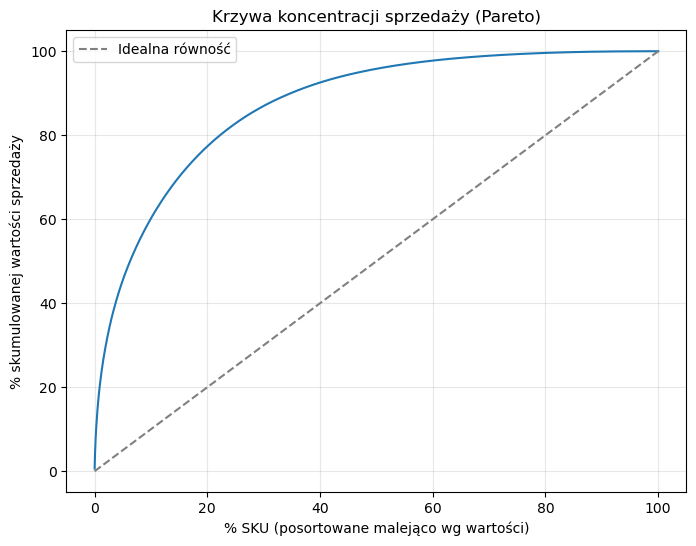

In [110]:
plt.figure(figsize=(8,6))
wartosc_per_towid['PozycjaProcentowa'] = (wartosc_per_towid.index + 1) / len(wartosc_per_towid) * 100
plt.plot(wartosc_per_towid['PozycjaProcentowa'], wartosc_per_towid['UdzialSkumulowany'])
plt.plot([0,100],[0,100], linestyle='--', color='gray', label='Idealna równość')
plt.xlabel('% SKU (posortowane malejąco wg wartości)')
plt.ylabel('% skumulowanej wartości sprzedaży')
plt.title('Krzywa koncentracji sprzedaży (Pareto)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [111]:
def kategoria_abc(udzial_skumulowany):
    if udzial_skumulowany <= 80:
        return 'A'
    elif udzial_skumulowany <= 95:
        return 'B'
    else:
        return 'C'

wartosc_per_towid['KategoriaABC'] = wartosc_per_towid['UdzialSkumulowany'].apply(kategoria_abc)
print(wartosc_per_towid['KategoriaABC'].value_counts())

KategoriaABC
C    6620
B    3084
A    2777
Name: count, dtype: int64


In [112]:
df_pelna_analiza = wartosc_per_towid.merge(
    ostatnia_sprzedaz[['TowId', 'KategoriaRotacji']], on='TowId', how='left'
)

# D = niska wartość (C) + brak aktywności (martwy)
df_pelna_analiza['KategoriaFinalna'] = df_pelna_analiza.apply(
    lambda r: 'D' if (r['KategoriaABC']=='C' and r['KategoriaRotacji']=='martwy') else r['KategoriaABC'],
    axis=1
)

print(df_pelna_analiza['KategoriaFinalna'].value_counts())

# Macierz kontrolna - sprawdź czy są A-kategorie które są martwe (to alarm!)
macierz = pd.crosstab(df_pelna_analiza['KategoriaABC'], df_pelna_analiza['KategoriaRotacji'])
print(macierz)

KategoriaFinalna
C    4136
B    3084
A    2777
D    2484
Name: count, dtype: int64
KategoriaRotacji  aktywny  martwy  sezonowy_poza_sezonem  zagrozony
KategoriaABC                                                       
A                    2503      49                      7        218
B                    1996     371                     59        658
C                    1735    2484                    474       1927


In [113]:
df_pelna_analiza.sample(10)

,TowId,Wartosc,UdzialProcentowy,UdzialSkumulowany,PozycjaProcentowa,KategoriaABC,KategoriaRotacji,KategoriaFinalna
12079,66134,7,0,100,97,C,martwy,D
10725,53711,42,0,100,86,C,sezonowy_poza_sezonem,C
11485,52960,19,0,100,92,C,sezonowy_poza_sezonem,C
6828,7369,284,0,97,55,C,martwy,D
5635,78447,463,0,94,45,B,aktywny,B
9104,67407,108,0,99,73,C,sezonowy_poza_sezonem,C
334,2978,"8,627",0,35,3,A,aktywny,A
9206,37341,103,0,99,74,C,martwy,D
2288,15151,"1,997",0,75,18,A,zagrozony,A
11126,36892,29,0,100,89,C,zagrozony,C


In [114]:
alarm_a_martwy = df_pelna_analiza[
    (df_pelna_analiza['KategoriaABC'] == 'A') & 
    (df_pelna_analiza['KategoriaRotacji'] == 'martwy')
].merge(
    df_fi_hard[['TowId', 'NazwaTow', 'NazwaAsort']].drop_duplicates(subset='TowId'),
    on='TowId', how='left'
).sort_values('Wartosc', ascending=False)

# Dołączmy też datę ostatniej sprzedaży dla kontekstu - kiedy dokładnie "umarły"
alarm_a_martwy = alarm_a_martwy.merge(
    ostatnia_sprzedaz[['TowId', 'OstatniaSprzedaz', 'DniOdOstatniejSprzedazy']],
    on='TowId', how='left'
)

print(f"Produkty kategorii A, które są martwe: {len(alarm_a_martwy)}")
wynik_alarm = alarm_a_martwy[
    ['TowId', 'NazwaTow', 'NazwaAsort', 'Wartosc', 'UdzialProcentowy', 'OstatniaSprzedaz', 'DniOdOstatniejSprzedazy']
].round({'Wartosc': 0, 'UdzialProcentowy': 3})

wynik_alarm

Produkty kategorii A, które są martwe: 49


,TowId,NazwaTow,NazwaAsort,Wartosc,UdzialProcentowy,OstatniaSprzedaz,DniOdOstatniejSprzedazy
0,50771,"WÓDKA 1906 38% 0,09L",3 WÓDKI I NAP.ALK POWYŻEJ 18%,"8,529",0,2023-07-29,917
1,51267,"WÓDKA LUBELSKA 3ZBOŻA 30% 0,2L",3 WÓDKI I NAP.ALK POWYŻEJ 18%,"7,046",0,2023-08-12,903
2,52563,PAPIEROSY ROTHMANS TWIST SSL 20SZT BAT,PAPIEROSY,"6,838",0,2024-03-14,688
3,54095,"NAPÓJ ALK LUBELSKA CYTRYNA 28% 0,1L",3 WÓDKI I NAP.ALK POWYŻEJ 18%,"5,084",0,2024-04-30,641
4,38284,PAPIEROSY ROTHMANS NAVY BLUE SS,PAPIEROSY,"4,883",0,2023-10-11,843
5,49431,PAPIEROSY RGD RED 100 20SZT PHILIP MORRIS,PAPIEROSY,"4,261",0,2023-11-18,805
6,49968,GOOGLE PLAY STORE 20-400,INNE,"4,008",0,2024-06-12,598
7,53141,SYROP MALINOWY 430ML SPAR,MARKA WŁASNA SPAR,"3,963",0,2024-07-20,560
8,54237,"NAPÓJ ALK LUBELSKA PORZECZKA 28% 0,1L",3 WÓDKI I NAP.ALK POWYŻEJ 18%,"3,951",0,2024-06-01,609
9,53647,CUKIERKI PROMOCJA KG,CUKIERKI,"3,939",0,2024-02-16,715


In [115]:
alarm_a_martwy = df_pelna_analiza[
    (df_pelna_analiza['KategoriaABC'] == 'A') & 
    (df_pelna_analiza['KategoriaRotacji'] == 'martwy')
].merge(
    df_fi_hard[['TowId', 'NazwaTow', 'NazwaAsort']].drop_duplicates(subset='TowId'),
    on='TowId', how='left'
).sort_values('Wartosc', ascending=False)

# Dołączmy datę ostatniej sprzedaży dla kontekstu
alarm_a_martwy = alarm_a_martwy.merge(
    ostatnia_sprzedaz[['TowId', 'OstatniaSprzedaz', 'DniOdOstatniejSprzedazy']],
    on='TowId', how='left'
)

print(f"Produkty kategorii A, które są martwe: {len(alarm_a_martwy)}")

wynik_alarm = alarm_a_martwy[
    ['TowId', 'NazwaTow', 'NazwaAsort', 'KategoriaFinalna', 'Wartosc', 
     'UdzialProcentowy', 'OstatniaSprzedaz', 'DniOdOstatniejSprzedazy']
].round({'Wartosc': 0, 'UdzialProcentowy': 3})

wynik_alarm

Produkty kategorii A, które są martwe: 49


,TowId,NazwaTow,NazwaAsort,KategoriaFinalna,Wartosc,UdzialProcentowy,OstatniaSprzedaz,DniOdOstatniejSprzedazy
0,50771,"WÓDKA 1906 38% 0,09L",3 WÓDKI I NAP.ALK POWYŻEJ 18%,A,"8,529",0,2023-07-29,917
1,51267,"WÓDKA LUBELSKA 3ZBOŻA 30% 0,2L",3 WÓDKI I NAP.ALK POWYŻEJ 18%,A,"7,046",0,2023-08-12,903
2,52563,PAPIEROSY ROTHMANS TWIST SSL 20SZT BAT,PAPIEROSY,A,"6,838",0,2024-03-14,688
3,54095,"NAPÓJ ALK LUBELSKA CYTRYNA 28% 0,1L",3 WÓDKI I NAP.ALK POWYŻEJ 18%,A,"5,084",0,2024-04-30,641
4,38284,PAPIEROSY ROTHMANS NAVY BLUE SS,PAPIEROSY,A,"4,883",0,2023-10-11,843
5,49431,PAPIEROSY RGD RED 100 20SZT PHILIP MORRIS,PAPIEROSY,A,"4,261",0,2023-11-18,805
6,49968,GOOGLE PLAY STORE 20-400,INNE,A,"4,008",0,2024-06-12,598
7,53141,SYROP MALINOWY 430ML SPAR,MARKA WŁASNA SPAR,A,"3,963",0,2024-07-20,560
8,54237,"NAPÓJ ALK LUBELSKA PORZECZKA 28% 0,1L",3 WÓDKI I NAP.ALK POWYŻEJ 18%,A,"3,951",0,2024-06-01,609
9,53647,CUKIERKI PROMOCJA KG,CUKIERKI,A,"3,939",0,2024-02-16,715


# ============================================================
# FINALNY PLIK — df_fi_soft z pełnym zestawem flag
# Rotacja + Sezonowość + ABC/D + Ważenie
# ============================================================

In [116]:


# Punkt wyjścia: df_fi_hard (wszystkie rekordy transakcyjne po hard-wykluczeniach)
df_fi_soft = df_fi_hard.copy()

# --- 1. Flagi rotacji (z ostatnia_sprzedaz / rotacja_towid) ---
df_fi_soft = df_fi_soft.merge(
    rotacja_towid[['TowId', 'OstatniaSprzedaz', 'DniOdOstatniejSprzedazy', 'KategoriaRotacji']],
    on='TowId', how='left'
)

# --- 2. Flaga sezonowości ---
df_fi_soft = df_fi_soft.merge(
    sezonowosc_pelna[['TowId', 'PrawdopodobnieSezonowy']],
    on='TowId', how='left'
)

# --- 3. Kategoria ABC/D (z df_pelna_analiza) ---
df_fi_soft = df_fi_soft.merge(
    df_pelna_analiza[['TowId', 'UdzialProcentowy', 'UdzialSkumulowany', 'KategoriaABC', 'KategoriaFinalna']],
    on='TowId', how='left'
)

# --- 4. Flaga towarów ważonych ---
df_fi_soft['JestWazony'] = df_fi_soft['TowId'].isin(lista_wazonych_towid)

# --- 5. Gotowe flagi boolowskie do szybkiego filtrowania ---
df_fi_soft['JestAktywny'] = df_fi_soft['KategoriaRotacji'] == 'aktywny'
df_fi_soft['JestSezonowyPozaSezonem'] = df_fi_soft['KategoriaRotacji'] == 'sezonowy_poza_sezonem'
df_fi_soft['WymagaUwagi'] = df_fi_soft['KategoriaRotacji'] == 'zagrozony'
df_fi_soft['JestMartwy'] = df_fi_soft['KategoriaRotacji'] == 'martwy'
df_fi_soft['NigdyNieSprzedany'] = df_fi_soft['KategoriaRotacji'] == 'nigdy_nie_sprzedany'
df_fi_soft['WykluczZPrognozy'] = df_fi_soft['KategoriaRotacji'].isin(['martwy', 'nigdy_nie_sprzedany'])

# Alarm: kluczowe (A), ale martwe - wymaga ręcznej weryfikacji, nie automatycznego wykluczenia
df_fi_soft['AlarmWazneMartwe'] = (
    (df_fi_soft['KategoriaABC'] == 'A') & (df_fi_soft['KategoriaRotacji'] == 'martwy')
)

# --- Podsumowanie przed zapisem ---
print(f"Rekordów: {len(df_fi_soft):,}")
print(f"Unikalnych TowId: {df_fi_soft['TowId'].nunique():,}")
print(f"\nKategoriaRotacji:\n{df_fi_soft.drop_duplicates('TowId')['KategoriaRotacji'].value_counts()}")
print(f"\nKategoriaFinalna (ABCD):\n{df_fi_soft.drop_duplicates('TowId')['KategoriaFinalna'].value_counts()}")
print(f"\nJestWazony:\n{df_fi_soft.drop_duplicates('TowId')['JestWazony'].value_counts()}")
print(f"\nAlarmWazneMartwe: {df_fi_soft.drop_duplicates('TowId')['AlarmWazneMartwe'].sum()} TowId")

Rekordów: 4,106,901
Unikalnych TowId: 19,692

KategoriaRotacji:
KategoriaRotacji
nigdy_nie_sprzedany      7211
aktywny                  6234
martwy                   2904
zagrozony                2803
sezonowy_poza_sezonem     540
Name: count, dtype: int64

KategoriaFinalna (ABCD):
KategoriaFinalna
C    4136
B    3084
A    2777
D    2484
Name: count, dtype: int64

JestWazony:
JestWazony
False    19454
True       238
Name: count, dtype: int64

AlarmWazneMartwe: 49 TowId


In [117]:
df_fi_soft.sample(5)

,DokId,Kolejnosc,NrPozycji,TowId,TypPoz,IloscPlus,IloscMinus,CenaPoRab,Wartosc,Data,...,KategoriaABC,KategoriaFinalna,JestWazony,JestAktywny,JestSezonowyPozaSezonem,WymagaUwagi,JestMartwy,NigdyNieSprzedany,WykluczZPrognozy,AlarmWazneMartwe
3260659,2019977,1,1,2417,4,1,0,3,3,2025-05-27,...,B,B,False,True,False,False,False,False,False,False
2739576,1894720,3,3,50122,4,1,0,4,4,2025-01-14,...,A,A,False,False,False,True,False,False,False,False
2176826,1759293,4,4,23945,4,1,0,2,2,2024-08-17,...,A,A,False,True,False,False,False,False,False,False
839543,1377480,5,5,271,4,1,0,3,3,2023-08-25,...,A,A,False,True,False,False,False,False,False,False
2780522,1904054,8,8,25709,4,1,0,7,7,2025-01-25,...,A,A,False,True,False,False,False,False,False,False


In [118]:
df_fi_soft.to_parquet(
    "dane/interim/fact_inka_soft_final.parquet",
    compression='zstd',
    index=False
)
print(f"Zapisano: {df_fi_soft.shape}")

Zapisano: (4106901, 48)


Dodatkowo — osobny, lekki plik ze słownikiem TowId (bez powtarzania w każdej transakcji), przydatny do szybkich raportów bez ładowania całej tabeli faktów:
Ten drugi plik (słownik) będzie szczególnie wygodny do przyszłej pracy — np. przy budowie prognozy sprzedaży, gdzie potrzebujesz szybko sprawdzić kategorię produktu bez przeszukiwania 4 milionów wierszy transakcji.

In [119]:
slownik_towid = df_fi_soft.drop_duplicates(subset='TowId')[
    ['TowId', 'NazwaTow', 'EAN', 'NazwaAsort', 
     'KategoriaRotacji', 'DniOdOstatniejSprzedazy', 'PrawdopodobnieSezonowy',
     'KategoriaABC', 'KategoriaFinalna', 'UdzialProcentowy', 
     'JestWazony', 'AlarmWazneMartwe']
].reset_index(drop=True)

slownik_towid.to_parquet(
    "dane/interim/slownik_towid_kategorie.parquet",
    compression='zstd',
    index=False
)
print(f"Zapisano słownik: {slownik_towid.shape}")

Zapisano słownik: (19692, 12)


In [120]:
df_fi_hard.columns

Index(['DokId', 'Kolejnosc', 'NrPozycji', 'TowId', 'TypPoz', 'IloscPlus', 'IloscMinus', 'CenaPoRab', 'Wartosc', 'Data', 'KolejnyWDniu', 'NrDok', 'TypDok', 'AktywnyDok', 'Razem', 'DoZaplaty',
       'Zaplacono', 'AsId', 'NazwaTow', 'EAN', 'Opis1', 'Producent', 'AktywnyTow', 'NazwaAsort', 'Dokument', 'WplywNaStan', 'MetodaLiczenia', 'Mnoznik', 'TypRuchu', 'CzyNiechciane',
       'NazwaTowCleanName', 'NazwaAsortCleanName'],
      dtype='str')

## Pełny kalendarz

In [121]:
# ============================================================
# Pełny kalendarz kalendarzowy z flagą otwarcia sklepu
# ============================================================

# 1. Zakres dat z danych
data_min = df_fi_hard['Data'].min()
data_max = df_fi_hard['Data'].max()

kalendarz_dni_pelny = pd.date_range(start=data_min, end=data_max, freq='D')
print(f"Wszystkich dni w zakresie: {len(kalendarz_dni_pelny)}")

# 2. Dni otwarcia sklepu - wywnioskowane z rzeczywistych transakcji sprzedaży
dni_otwarte = set(df_sprzedaz['Data'].dt.normalize().unique())
print(f"Dni z realną sprzedażą (otwarte): {len(dni_otwarte)}")

# 3. Budujemy DataFrame kalendarza dni z podstawowymi atrybutami
df_dni_kalendarz = pd.DataFrame({'Data': kalendarz_dni_pelny})

df_dni_kalendarz['CzySklepOtwarty'] = df_dni_kalendarz['Data'].isin(dni_otwarte)
df_dni_kalendarz['DzienTygodnia'] = df_dni_kalendarz['Data'].dt.dayofweek  # 0=pon, 6=niedz
df_dni_kalendarz['NazwaDnia'] = df_dni_kalendarz['Data'].dt.day_name()
df_dni_kalendarz['CzyNiedziela'] = df_dni_kalendarz['DzienTygodnia'] == 6
df_dni_kalendarz['CzySobota'] = df_dni_kalendarz['DzienTygodnia'] == 5

print(f"\nRozkład otwarcia wg dnia tygodnia:")
print(df_dni_kalendarz.groupby('NazwaDnia')['CzySklepOtwarty'].agg(['sum', 'count']))

Wszystkich dni w zakresie: 1127
Dni z realną sprzedażą (otwarte): 952

Rozkład otwarcia wg dnia tygodnia:
           sum  count
NazwaDnia            
Friday     156    161
Monday     153    161
Saturday   157    161
Sunday      21    161
Thursday   153    161
Tuesday    157    161
Wednesday  155    161


In [122]:
pl_holidays = holidays.Poland(years=range(data_min.year, data_max.year + 1))

df_dni_kalendarz['CzySwieto'] = df_dni_kalendarz['Data'].apply(lambda d: d in pl_holidays)
df_dni_kalendarz['NazwaSwieta'] = df_dni_kalendarz['Data'].apply(lambda d: pl_holidays.get(d, None))

print(f"\nDni świąteczne w zakresie: {df_dni_kalendarz['CzySwieto'].sum()}")
print(df_dni_kalendarz[df_dni_kalendarz['CzySwieto']][['Data', 'NazwaSwieta', 'CzySklepOtwarty']].head(20))


Dni świąteczne w zakresie: 42
          Data                       NazwaSwieta  CzySklepOtwarty
0   2023-01-01                    New Year's Day            False
5   2023-01-06                          Epiphany            False
98  2023-04-09                     Easter Sunday            False
99  2023-04-10                     Easter Monday            False
120 2023-05-01                      National Day            False
122 2023-05-03  National Day of the Third of May            False
147 2023-05-28                         Pentecost            False
158 2023-06-08                    Corpus Christi            False
226 2023-08-15                    Assumption Day            False
304 2023-11-01                   All Saints' Day            False
314 2023-11-11         National Independence Day            False
358 2023-12-25                     Christmas Day            False
359 2023-12-26           Second Day of Christmas            False
365 2024-01-01                    New Year's 

In [123]:
# ============================================================
# Budowa pełnego kalendarza TowId × Data — Z PRZYCIĘCIEM do okresu życia
# ============================================================

towid_do_kalendarza = df_fi_soft[
    df_fi_soft['KategoriaRotacji'] != 'nigdy_nie_sprzedany'
]['TowId'].unique()

print(f"TowId do kalendarza: {len(towid_do_kalendarza)}")

# 1. Pełny cross join (jak dotychczas)
pelny_kalendarz = pd.MultiIndex.from_product(
    [towid_do_kalendarza, kalendarz_dni_pelny],
    names=['TowId', 'Data']
).to_frame(index=False)

print(f"Rozmiar przed przycięciem: {len(pelny_kalendarz):,} wierszy")

# 2. PRZYCINAMY od razu — okres życia per TowId (+bufor)
zakres_zycia = df_sprzedaz.groupby('TowId')['Data'].agg(['min', 'max']).reset_index()
zakres_zycia.columns = ['TowId', 'PierwszaSprzedaz', 'OstatniaSprzedazTowId']

pelny_kalendarz = pelny_kalendarz.merge(zakres_zycia, on='TowId', how='left')

bufor_dni = 30
pelny_kalendarz = pelny_kalendarz[
    (pelny_kalendarz['Data'] >= pelny_kalendarz['PierwszaSprzedaz'] - pd.Timedelta(days=bufor_dni)) &
    (pelny_kalendarz['Data'] <= pelny_kalendarz['OstatniaSprzedazTowId'] + pd.Timedelta(days=bufor_dni))
].copy()

print(f"Rozmiar po przycięciu:     {len(pelny_kalendarz):,} wierszy")

# 3. Dopiero teraz reszta merge'y — na mniejszym, przyciętym zbiorze
pelny_kalendarz = pelny_kalendarz.merge(df_dni_kalendarz, on='Data', how='left')

sprzedaz_dzienna = df_sprzedaz.groupby(['TowId', 'Data']).agg(
    Wartosc=('Wartosc', 'sum'),
    Ilosc=('IloscPlus', 'sum'),
    LiczbaTransakcji=('TowId', 'count')
).reset_index()

pelny_kalendarz = pelny_kalendarz.merge(sprzedaz_dzienna, on=['TowId', 'Data'], how='left')
pelny_kalendarz['Wartosc'] = pelny_kalendarz['Wartosc'].fillna(0)
pelny_kalendarz['Ilosc'] = pelny_kalendarz['Ilosc'].fillna(0)
pelny_kalendarz['LiczbaTransakcji'] = pelny_kalendarz['LiczbaTransakcji'].fillna(0).astype(int)

# 4. Cena (skoro już przy tym jesteśmy - dołączmy od razu, żeby nie robić tego osobno)
cena_dzienna = df_sprzedaz.groupby(['TowId', 'Data']).agg(
    SumaWartosci=('Wartosc', 'sum'),
    SumaIlosci=('IloscPlus', 'sum')
).reset_index()
cena_dzienna['CenaDzienna'] = cena_dzienna['SumaWartosci'] / cena_dzienna['SumaIlosci']
cena_dzienna = cena_dzienna[['TowId', 'Data', 'CenaDzienna']]

pelny_kalendarz = pelny_kalendarz.merge(cena_dzienna, on=['TowId', 'Data'], how='left')
pelny_kalendarz = pelny_kalendarz.sort_values(['TowId', 'Data'])
pelny_kalendarz['CenaOstatniaZnana'] = pelny_kalendarz.groupby('TowId')['CenaDzienna'].ffill()
pelny_kalendarz['ProduktJeszczeNieSprzedawany'] = pelny_kalendarz['CenaOstatniaZnana'].isna()

# 5. Nazwy i kategorie
pelny_kalendarz = pelny_kalendarz.merge(
    df_fi_hard[['TowId', 'NazwaTow']].drop_duplicates(subset='TowId'),
    on='TowId', how='left'
)
pelny_kalendarz = pelny_kalendarz.merge(
    slownik_towid[['TowId', 'KategoriaRotacji', 'KategoriaFinalna', 'PrawdopodobnieSezonowy', 'JestWazony']],
    on='TowId', how='left'
)

# 6. Optymalizacja typów danych (dodatkowa redukcja pamięci)
pelny_kalendarz['TowId'] = pelny_kalendarz['TowId'].astype('int32')
pelny_kalendarz['Ilosc'] = pelny_kalendarz['Ilosc'].astype('float32')
pelny_kalendarz['Wartosc'] = pelny_kalendarz['Wartosc'].astype('float32')
pelny_kalendarz['LiczbaTransakcji'] = pelny_kalendarz['LiczbaTransakcji'].astype('int16')
pelny_kalendarz['KategoriaRotacji'] = pelny_kalendarz['KategoriaRotacji'].astype('category')
pelny_kalendarz['KategoriaFinalna'] = pelny_kalendarz['KategoriaFinalna'].astype('category')

print(f"\nFinalny rozmiar: {pelny_kalendarz.shape}")
print(f"Pamięć: {pelny_kalendarz.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

TowId do kalendarza: 12481
Rozmiar przed przycięciem: 14,066,087 wierszy
Rozmiar po przycięciu:     7,429,302 wierszy

Finalny rozmiar: (7429302, 22)
Pamięć: 1205.0 MB


In [124]:
pelny_kalendarz

,TowId,Data,PierwszaSprzedaz,OstatniaSprzedazTowId,CzySklepOtwarty,DzienTygodnia,NazwaDnia,CzyNiedziela,CzySobota,CzySwieto,...,Ilosc,LiczbaTransakcji,CenaDzienna,CenaOstatniaZnana,ProduktJeszczeNieSprzedawany,NazwaTow,KategoriaRotacji,KategoriaFinalna,PrawdopodobnieSezonowy,JestWazony
0,15,2023-01-05,2023-02-04,2025-12-01,True,3,Thursday,False,False,False,...,0,0,NaN,NaN,True,SOS TABASCO RED 57ML DEVELEY,aktywny,B,False,False
1,15,2023-01-06,2023-02-04,2025-12-01,False,4,Friday,False,False,True,...,0,0,NaN,NaN,True,SOS TABASCO RED 57ML DEVELEY,aktywny,B,False,False
2,15,2023-01-07,2023-02-04,2025-12-01,True,5,Saturday,False,True,False,...,0,0,NaN,NaN,True,SOS TABASCO RED 57ML DEVELEY,aktywny,B,False,False
3,15,2023-01-08,2023-02-04,2025-12-01,False,6,Sunday,True,False,False,...,0,0,NaN,NaN,True,SOS TABASCO RED 57ML DEVELEY,aktywny,B,False,False
4,15,2023-01-09,2023-02-04,2025-12-01,True,0,Monday,False,False,False,...,0,0,NaN,NaN,True,SOS TABASCO RED 57ML DEVELEY,aktywny,B,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7429297,81360,2026-01-27,2025-11-14,2026-01-29,True,1,Tuesday,False,False,False,...,0,0,NaN,10,False,"BARSZCZ CZERWONY 0,85L ORYGINALNY SOK",aktywny,C,True,False
7429298,81360,2026-01-28,2025-11-14,2026-01-29,True,2,Wednesday,False,False,False,...,0,0,NaN,10,False,"BARSZCZ CZERWONY 0,85L ORYGINALNY SOK",aktywny,C,True,False
7429299,81360,2026-01-29,2025-11-14,2026-01-29,True,3,Thursday,False,False,False,...,1,1,10,10,False,"BARSZCZ CZERWONY 0,85L ORYGINALNY SOK",aktywny,C,True,False
7429300,81360,2026-01-30,2025-11-14,2026-01-29,True,4,Friday,False,False,False,...,0,0,NaN,10,False,"BARSZCZ CZERWONY 0,85L ORYGINALNY SOK",aktywny,C,True,False


In [125]:
print(f"Rozmiar: {pelny_kalendarz.shape}")
print(f"Pamięć: {pelny_kalendarz.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\nKolumny: {pelny_kalendarz.columns.tolist()}")

# Szybki sanity-check przed zapisem
print(f"\nBrakujące wartości per kolumna:")
print(pelny_kalendarz.isna().sum())

Rozmiar: (7429302, 22)
Pamięć: 1205.0 MB

Kolumny: ['TowId', 'Data', 'PierwszaSprzedaz', 'OstatniaSprzedazTowId', 'CzySklepOtwarty', 'DzienTygodnia', 'NazwaDnia', 'CzyNiedziela', 'CzySobota', 'CzySwieto', 'NazwaSwieta', 'Wartosc', 'Ilosc', 'LiczbaTransakcji', 'CenaDzienna', 'CenaOstatniaZnana', 'ProduktJeszczeNieSprzedawany', 'NazwaTow', 'KategoriaRotacji', 'KategoriaFinalna', 'PrawdopodobnieSezonowy', 'JestWazony']

Brakujące wartości per kolumna:
TowId                                 0
Data                                  0
PierwszaSprzedaz                      0
OstatniaSprzedazTowId                 0
CzySklepOtwarty                       0
DzienTygodnia                         0
NazwaDnia                             0
CzyNiedziela                          0
CzySobota                             0
CzySwieto                             0
NazwaSwieta                     7155051
Wartosc                               0
Ilosc                                 0
LiczbaTransakcji           

In [126]:
pelny_kalendarz.to_parquet(
    "dane/interim/kalendarz_pelny_towid.parquet",
    compression='zstd',
    index=False
)

In [127]:
df_fi_hard.to_parquet(
    "dane/interim/fact_inka_hard_records_2023_2026.parquet",
    compression='zstd',
    index=False
)

In [128]:
# Sprawdzenie ciągłości danych
sprawdzenie_ciaglosci = pelny_kalendarz.groupby('TowId')['Data'].agg(['min', 'max', 'count']).reset_index()
sprawdzenie_ciaglosci['OczekiwanaLiczbaDni'] = (
    (sprawdzenie_ciaglosci['max'] - sprawdzenie_ciaglosci['min']).dt.days + 1
)
sprawdzenie_ciaglosci['CzyCiagly'] = (
    sprawdzenie_ciaglosci['count'] == sprawdzenie_ciaglosci['OczekiwanaLiczbaDni']
)

print(f"TowId z ciągłym zakresem dat: {sprawdzenie_ciaglosci['CzyCiagly'].sum()}")
print(f"TowId z lukami: {(~sprawdzenie_ciaglosci['CzyCiagly']).sum()}")

print(sprawdzenie_ciaglosci[~sprawdzenie_ciaglosci['CzyCiagly']].head(10))

TowId z ciągłym zakresem dat: 12481
TowId z lukami: 0
Empty DataFrame
Columns: [TowId, min, max, count, OczekiwanaLiczbaDni, CzyCiagly]
Index: []


In [131]:
wszystkie_towid = set(df_fi_hard['TowId'].unique())
towid_ze_sprzedaza = set(df_fi_hard[df_fi_hard['TypRuchu']=='sprzedaz']['TowId'].unique())
towid_bez_sprzedazy = wszystkie_towid - towid_ze_sprzedaza

print(f"TowId bez żadnej sprzedaży: {len(towid_bez_sprzedazy):,}")

# I ile REKORDÓW (wierszy, dowolnego typu) dotyczy tych właśnie TowId
rekordy_bez_sprzedazy = df_fi_hard[df_fi_hard['TowId'].isin(towid_bez_sprzedazy)]
print(f"Rekordów (dowolnego typu) dla TowId bez sprzedaży: {len(rekordy_bez_sprzedazy):,}")

TowId bez żadnej sprzedaży: 7,211
Rekordów (dowolnego typu) dla TowId bez sprzedaży: 49,569


# Filtry "SOFT"

## Soft filtrowanie — po TowId/SKU


### Kryterium 2: Towary ważone per TowId  
- wyrzucamy TowId z ułamkowymi IloscPlus
- z wyjątkami (pieczywo - połówki)

---

# Metryki

### Główne:

* Ilosc_sprzedazy      — ile jednostek sprzedano (to optymalizujemy)
* Ilosc_transakcji     — liczba transakcji sprzedaży
* Dni_ze_sprzedaza     — ile dni miało sprzedaż
* Pct_dni_zerowych     — % dni bez sprzedaży
* Avg_dzienna_ilosc    — średnia dzienna ilość sprzedaży
* Ilosc_SKU            — liczba produktów w kategorii
---
### Pomocnicze — do cash flow:
* Wartosc_sprzedazy         — łączne obroty (oszacowanie cash flow)
* Avg_wartosc_per_SKU       — średnia wartość per produkt
* Ilosc_zamowien            — liczba PZ (przyjęć z magazynu)
* Avg_wartosc_zamowienia    — średnia wartość jednego zamówienia PZ
---
### Pozostałe:
- KategoriaABC (A/B/C)

### Per SKU (decyzja operacyjna — później):
- te same metryki per TowId
- KategoriaABC per SKU

### Cash flow / Working Capital:
- COGS miesięczny (~367k zł)
- Working Capital (~92k zł przy tygodniowym cyklu)
- potwierdzenie częstotliwości zamówień z PZ

---

# Terminy branżowe / domenowe

### Cash flow zakupowy:
- OTB (Open-To-Buy) — budżet dostępny na zakupy w danym okresie
- COGS (Cost of Goods Sold) — koszt sprzedanych towarów

### Zamrożony kapitał:
- Working Capital — kapitał obrotowy zamrożony w zapasie
- Inventory Value — wartość zapasu
- DOS (Days of Supply) — ile dni zapasu mamy na stanie
- DIO (Days Inventory Outstanding) — ile dni towar leży w magazynie zanim zostanie sprzedany

### Dead Stock:
- Obsolete Inventory — przestarzały/przeterminowany zapas
- Slow Movers — towary z niską rotacją
- Dead Stock — towary bez ruchu
- Shrinkage — straty (kradzieże, uszkodzenia, przeterminowanie)

### Rotacja:
- Inventory Turnover — wskaźnik rotacji zapasów (obroty / średni zapas)
- Sell-Through Rate — % sprzedanego towaru z dostarczonego

### Kategoryzacja:
- ABC Analysis — podział na kategorie A/B/C wg wartości/rotacji
- Pareto (80/20) — 20% SKU generuje 80% obrotów

---
# PL vs EN - polskie "odpowiedniki".
---
### Używane zamiennie PL/EN:
- DOS / Pokrycie zapasu (dni)
- Working Capital / Kapitał obrotowy
- Sell-Through Rate / Wskaźnik sprzedaży

### Częściej po polsku:
- Rotacja zapasów (nie Inventory Turnover)
- Zapas / Stan magazynowy (nie Inventory)
- Zamówienie (nie Order)

### Powszechnie znane po angielsku (bez polskich wersji):
- OTB, COGS, ABC Analysis
- Dead Stock, Slow Movers
- Inventory Turnover
- KPI, Dashboard

---